In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('DataAnalyst.csv')
df.head()

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True


In [2]:
df.shape

(2253, 16)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         2253 non-null   int64  
 1   Job Title          2253 non-null   str    
 2   Salary Estimate    2253 non-null   str    
 3   Job Description    2253 non-null   str    
 4   Rating             2253 non-null   float64
 5   Company Name       2252 non-null   str    
 6   Location           2253 non-null   str    
 7   Headquarters       2253 non-null   str    
 8   Size               2253 non-null   str    
 9   Founded            2253 non-null   int64  
 10  Type of ownership  2253 non-null   str    
 11  Industry           2253 non-null   str    
 12  Sector             2253 non-null   str    
 13  Revenue            2253 non-null   str    
 14  Competitors        2253 non-null   str    
 15  Easy Apply         2253 non-null   str    
dtypes: float64(1), int64(2), str(13)
me

In [10]:
df.isnull().sum()

Unnamed: 0           0
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         1
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
Easy Apply           0
dtype: int64

In [11]:
df['sal_min'] = df['Salary Estimate'].str.split('-').str[0].str.strip()
df['sal_max'] = df['Salary Estimate'].str.split('-').str[1].str.strip()
df['sal_avg'] = (df['sal_min'].astype(float) + df['sal_max'].astype(float)) / 2

df[['Company Name', 'Salary Estimate', 'sal_min', 'sal_max', 'sal_avg']].head()

ValueError: could not convert string to float: ''

In [12]:
# Find the problematic rows
mask = (df['sal_min'] == '') | (df['sal_max'] == '')
print(df[mask]['Salary Estimate'])

2149    -1
Name: Salary Estimate, dtype: str


In [13]:
# Drop the row with -1
df = df[df['Salary Estimate'] != '-1']

# Now extract min, max, avg
df['sal_min'] = df['Salary Estimate'].str.split('-').str[0].str.strip().astype(float)
df['sal_max'] = df['Salary Estimate'].str.split('-').str[1].str.strip().astype(float)
df['sal_avg'] = (df['sal_min'] + df['sal_max']) / 2

df[['Company Name', 'Salary Estimate', 'sal_min', 'sal_max', 'sal_avg']].head()

,Company Name,Salary Estimate,sal_min,sal_max,sal_avg
0,Vera Institute of Justice,37-66,37.0,66.0,51.5
1,Visiting Nurse Service of New York,37-66,37.0,66.0,51.5
2,Squarespace,37-66,37.0,66.0,51.5
3,Celerity,37-66,37.0,66.0,51.5
4,FanDuel,37-66,37.0,66.0,51.5


In [14]:
skills = ['Python', 'SQL', 'Excel', 'Tableau', 'Power BI', 'R', 'Spark', 'AWS', 'Machine Learning']

for skill in skills:
    df[skill] = df['Job Description'].str.contains(skill, case=False).astype(int)

# Count how many job postings mention each skill
skill_counts = df[skills].sum().sort_values(ascending=False)
print(skill_counts)

R                   2251
SQL                 1388
Excel               1353
Python               637
Tableau              620
AWS                  275
Power BI             180
Machine Learning     180
Spark                 89
dtype: int64


In [15]:
import re

for skill in skills:
    if skill == 'R':
        # Use word boundary to match only standalone "R"
        df[skill] = df['Job Description'].str.contains(r'\bR\b', case=False).astype(int)
    else:
        df[skill] = df['Job Description'].str.contains(skill, case=False).astype(int)

skill_counts = df[skills].sum().sort_values(ascending=False)
print(skill_counts)

SQL                 1388
Excel               1353
Python               637
Tableau              620
R                    441
AWS                  275
Power BI             180
Machine Learning     180
Spark                 89
dtype: int64


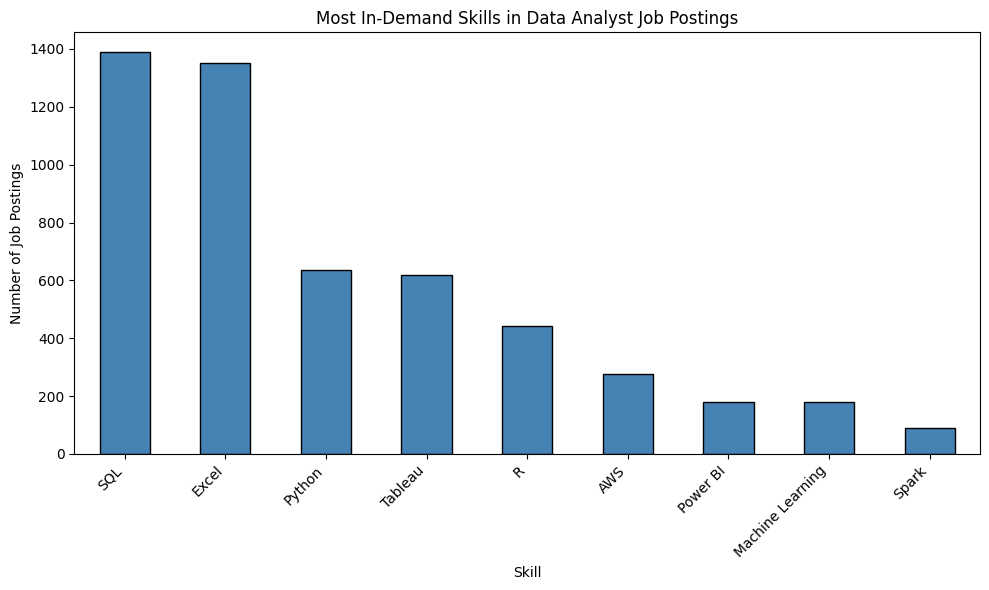

In [16]:
plt.figure(figsize=(10, 6))
skill_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Most In-Demand Skills in Data Analyst Job Postings')
plt.xlabel('Skill')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
skill_salary = {skill: df[df[skill] == 1]['sal_avg'].mean() for skill in skills}
skill_salary = pd.Series(skill_salary).sort_values(ascending=False)
print(skill_salary)

Python              74.733909
Tableau             74.243548
Machine Learning    73.977778
R                   73.369615
Spark               72.073034
SQL                 71.796470
Excel               71.666667
Power BI            69.844444
AWS                 69.450909
dtype: float64


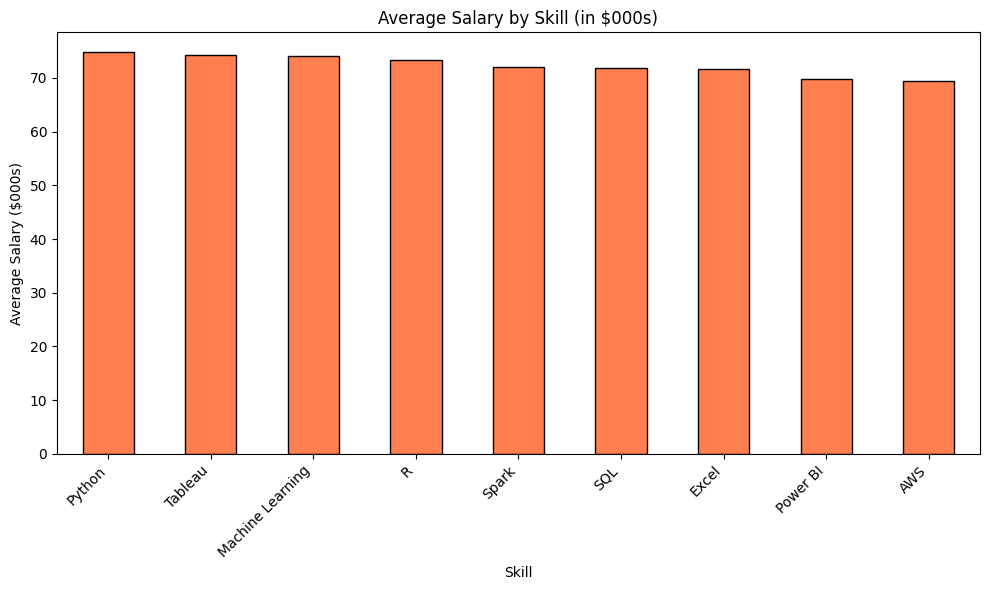

In [18]:
plt.figure(figsize=(10, 6))
skill_salary.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Salary by Skill (in $000s)')
plt.xlabel('Skill')
plt.ylabel('Average Salary ($000s)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

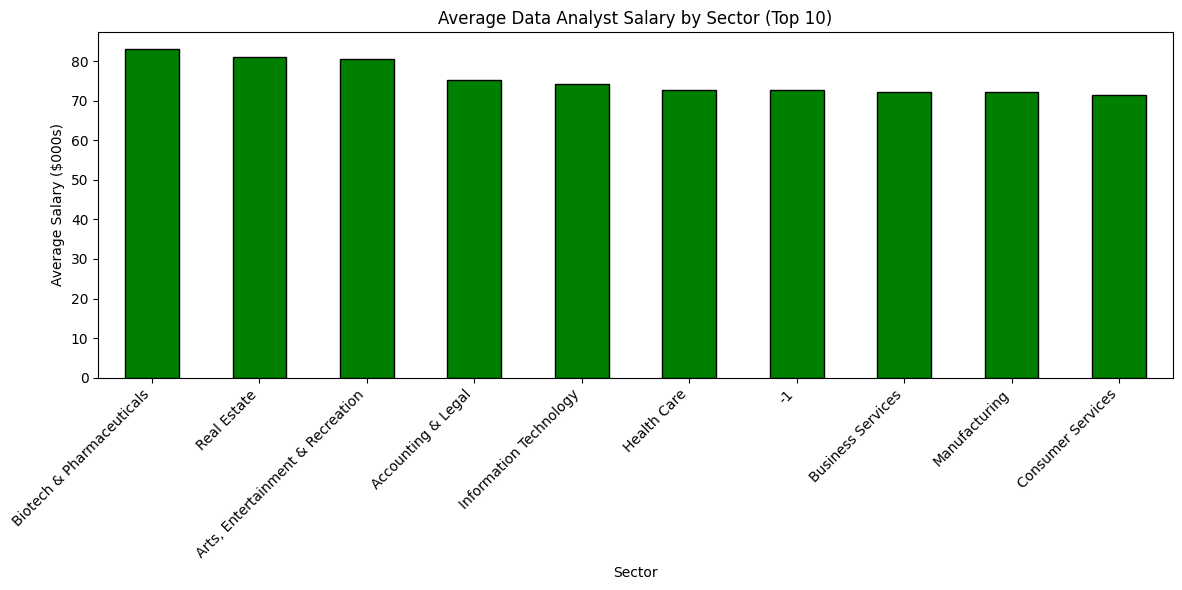

In [19]:
sector_salary = df.groupby('Sector')['sal_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sector_salary.plot(kind='bar', color='green', edgecolor='black')
plt.title('Average Data Analyst Salary by Sector (Top 10)')
plt.xlabel('Sector')
plt.ylabel('Average Salary ($000s)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
df.to_csv('job_market_cleaned.csv', index=False)
print('Saved!')

Saved!
